In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [2]:
# Step 1: Create synthetic data
X, y = make_blobs(n_samples=500, n_features=2, centers=3, random_state=23)

# Step 2: Initialize random centroids
k = 3
clusters = {}
np.random.seed(23)
for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],)) - 1)
    clusters[idx] = {'center': center, 'points': []}

In [3]:
# Step 3: Euclidean distance function
def distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

In [4]:
# Step 4: Assign points to nearest centroid
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []
        curr_x = X[idx]
        for i in range(k):
            dist.append(distance(curr_x, clusters[i]['center']))
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

In [5]:
# Step 5: Update centroids
def update_clusters(clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            clusters[i]['center'] = points.mean(axis=0)
            clusters[i]['points'] = []
    return clusters

In [6]:
# Step 6: Predict cluster for each point
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i], clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

In [7]:
# Step 7: Run K-Means iterations
for i in range(10):  # iterate multiple times for convergence
    clusters = assign_clusters(X, clusters)
    clusters = update_clusters(clusters)

In [8]:
# Step 8: Predict clusters
pred = pred_cluster(X, clusters)

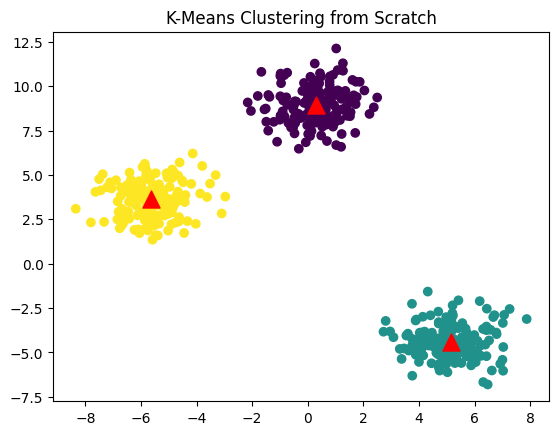

In [9]:
# Step 9: Plot final clusters
plt.scatter(X[:,0], X[:,1], c=pred)
for i in range(k):
    plt.scatter(clusters[i]['center'][0], clusters[i]['center'][1], marker='^', c='red', s=150)
plt.title("K-Means Clustering from Scratch")
plt.show()